In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from IPython.display import clear_output  # Importante para manter o notebook limpo
import numpy as np

PARAM_GOLD = {
    "batch_size": 64,
    "image_size": 64,
    "nc": 3,
    "nz": 100,
    "ngf": 128,
    "ndf": 64,
    "lr_g": 0.0003,
    "lr_d": 0.0001,
    "beta1": 0.5,
    "epochs": 250,             # Configurado para 250 épocas de refinamento
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

print(f"Dispositivo de treino ativo: {PARAM_GOLD['device']}")

Dispositivo de treino ativo: cuda


In [3]:
# Definindo as transformações com Data Augmentation para expandir a variedade visual
transform = transforms.Compose([
    transforms.Resize(PARAM_GOLD["image_size"] + 8),
    transforms.RandomCrop(PARAM_GOLD["image_size"]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

print("Baixando e unificando as divisões do dataset Oxford Flowers 102...")

# Carrega os 3 splits aceitos pelo torchvision
train_dataset = datasets.Flowers102(root='./data', split='train', download=True, transform=transform)
val_dataset   = datasets.Flowers102(root='./data', split='val', download=True, transform=transform)
test_dataset  = datasets.Flowers102(root='./data', split='test', download=True, transform=transform)

# Junta tudo em um único dataset massivo usando o ConcatDataset
dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset, test_dataset])

# Cria o DataLoader apontando para o dataset unificado
dataloader = DataLoader(dataset, batch_size=PARAM_GOLD["batch_size"], shuffle=True, num_workers=2)

print(f"Sucesso! Dataset unificado criado.")
print(f"-> Imagens de treino original: {len(train_dataset)}")
print(f"-> Imagens de validação: {len(val_dataset)}")
print(f"-> Imagens de teste: {len(test_dataset)}")
print(f"-> TOTAL unificado para a DCGAN: {len(dataset)} imagens.")

Baixando e unificando as divisões do dataset Oxford Flowers 102...


100%|██████████| 345M/345M [00:16<00:00, 21.1MB/s]
100%|██████████| 502/502 [00:00<00:00, 352kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 25.0MB/s]


Sucesso! Dataset unificado criado.
-> Imagens de treino original: 1020
-> Imagens de validação: 1020
-> Imagens de teste: 6149
-> TOTAL unificado para a DCGAN: 8189 imagens.


In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        nz, ngf, nc = PARAM_GOLD["nz"], PARAM_GOLD["ngf"], PARAM_GOLD["nc"]
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        nc, ndf = PARAM_GOLD["nc"], PARAM_GOLD["ndf"]
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, input):
        return self.main(input)

netG = Generator().to(PARAM_GOLD["device"])
netG.apply(weights_init)

netD = Discriminator().to(PARAM_GOLD["device"])
netD.apply(weights_init)
print("Redes prontas para a maratona de 250 épocas.")

Redes prontas para a maratona de 250 épocas.


In [5]:
criterion = nn.BCELoss()
fixed_noise = torch.randn(64, PARAM_GOLD["nz"], 1, 1, device=PARAM_GOLD["device"])

optimizerD = optim.Adam(netD.parameters(), lr=PARAM_GOLD["lr_d"], betas=(PARAM_GOLD["beta1"], 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=PARAM_GOLD["lr_g"], betas=(PARAM_GOLD["beta1"], 0.999))

G_losses = []
D_losses = []
final_grid = None

Progresso: Época [250/250] | Loss_D: 1.3613 | Loss_G: 0.7708


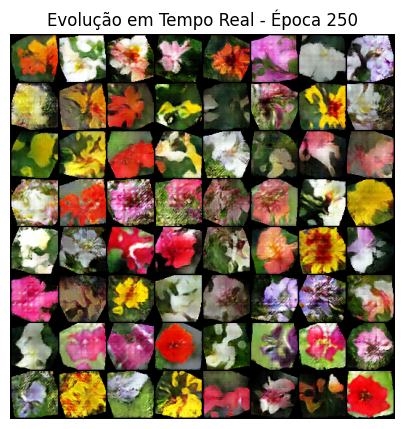

Treinamento de 250 épocas concluído com sucesso!


In [6]:
print("Iniciando treinamento de 250 épocas. Prepare o café...")

for epoch in range(PARAM_GOLD["epochs"]):
    for i, data in enumerate(dataloader, 0):
        real_cpu = data[0].to(PARAM_GOLD["device"])
        b_size = real_cpu.size(0)

        # -----------------------------------------------------------------
        # Treino do Discriminador
        # -----------------------------------------------------------------
        netD.zero_grad()
        label = torch.rand((b_size,), device=PARAM_GOLD["device"]) * 0.15 + 0.85
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, PARAM_GOLD["nz"], 1, 1, device=PARAM_GOLD["device"])
        fake = netG(noise)

        label = torch.rand((b_size,), device=PARAM_GOLD["device"]) * 0.1
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()

        errD = errD_real + errD_fake

        if errD.item() > 0.22:
            optimizerD.step()

        # -----------------------------------------------------------------
        # Treino do Gerador
        # -----------------------------------------------------------------
        netG.zero_grad()
        label = torch.rand((b_size,), device=PARAM_GOLD["device"]) * 0.1 + 0.9
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

    # Monitorização visual limpa a cada 10 épocas
    if (epoch + 1) % 10 == 0 or epoch == 0:
        clear_output(wait=True) # Apaga o plot anterior para poupar a RAM do navegador
        print(f'Progresso: Época [{epoch+1}/{PARAM_GOLD["epochs"]}] | Loss_D: {errD.item():.4f} | Loss_G: {errG.item():.4f}')
        with torch.no_grad():
            fake_display = netG(fixed_noise).detach().cpu()
        grid = vutils.make_grid(fake_display, padding=2, normalize=True)

        plt.figure(figsize=(5,5))
        plt.axis("off")
        plt.title(f"Evolução em Tempo Real - Época {epoch+1}")
        plt.imshow(np.transpose(grid, (1,2,0)))
        plt.show()

with torch.no_grad():
    fake_display = netG(fixed_noise).detach().cpu()
final_grid = vutils.make_grid(fake_display, padding=2, normalize=True)
print("Treinamento de 250 épocas concluído com sucesso!")

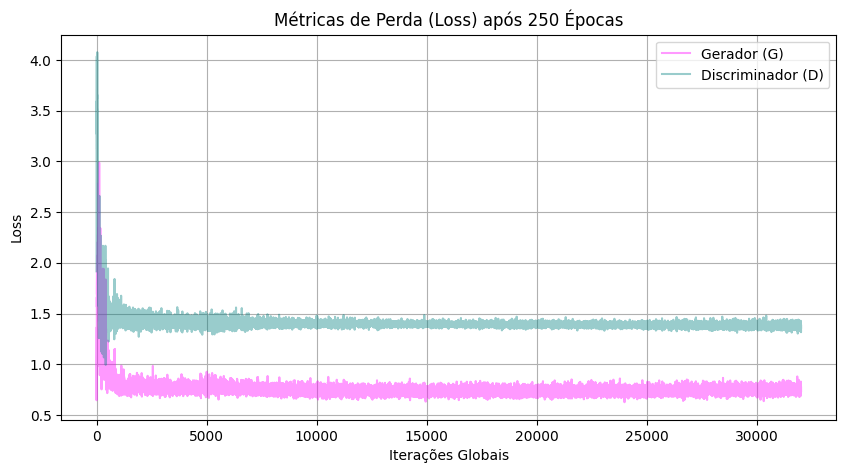

In [7]:
plt.figure(figsize=(10,5))
plt.title("Métricas de Perda (Loss) após 250 Épocas")
plt.plot(G_losses, label="Gerador (G)", color="magenta", alpha=0.4)
plt.plot(D_losses, label="Discriminador (D)", color="teal", alpha=0.4)
plt.xlabel("Iterações Globais")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_250_epocas.png")
plt.show()

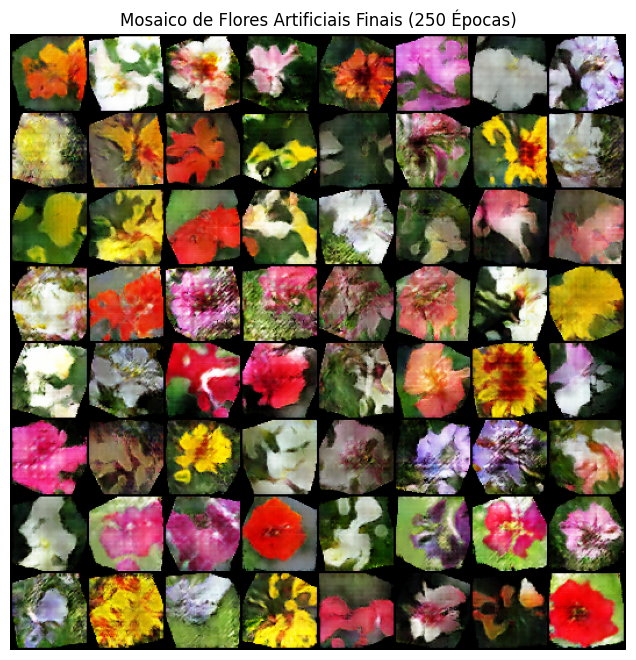

In [8]:
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Mosaico de Flores Artificiais Finais (250 Épocas)")
plt.imshow(np.transpose(final_grid, (1,2,0)))
plt.savefig("flores_250_epocas.png")
plt.show()